# Task 1: Diagnostic Enhancement of Chest X-Rays

This notebook demonstrates a complete image processing pipeline for
enhancing raw chest X-ray images. The operations include histogram
equalization, color mapping, color balance correction, thresholding,
logarithmic transformation, and power-law (gamma) correction.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Create output directory
os.makedirs('output', exist_ok=True)

## 1. Load and Display
Load the sample chest X-ray as a grayscale image and display it.

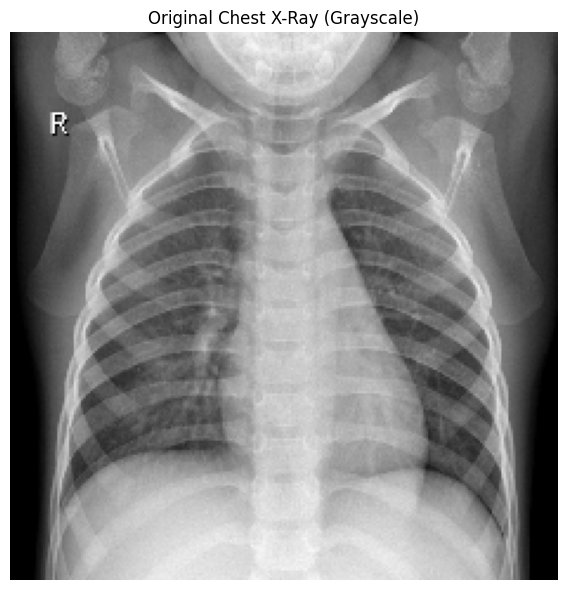

Image shape: (232, 232), dtype: uint8
Intensity range: [0, 255]


In [2]:
img = cv2.imread('data/sample_xray.png', cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError("Could not load data/sample_xray.png")

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap='gray')
plt.title('Original Chest X-Ray (Grayscale)')
plt.axis('off')
plt.tight_layout()
plt.savefig('output/01_original.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Image shape: {img.shape}, dtype: {img.dtype}")
print(f"Intensity range: [{img.min()}, {img.max()}]")

## 2. Contrast Enhancement — Histogram Equalization
Apply histogram equalization to redistribute pixel intensities,
making lung structures far more visible.

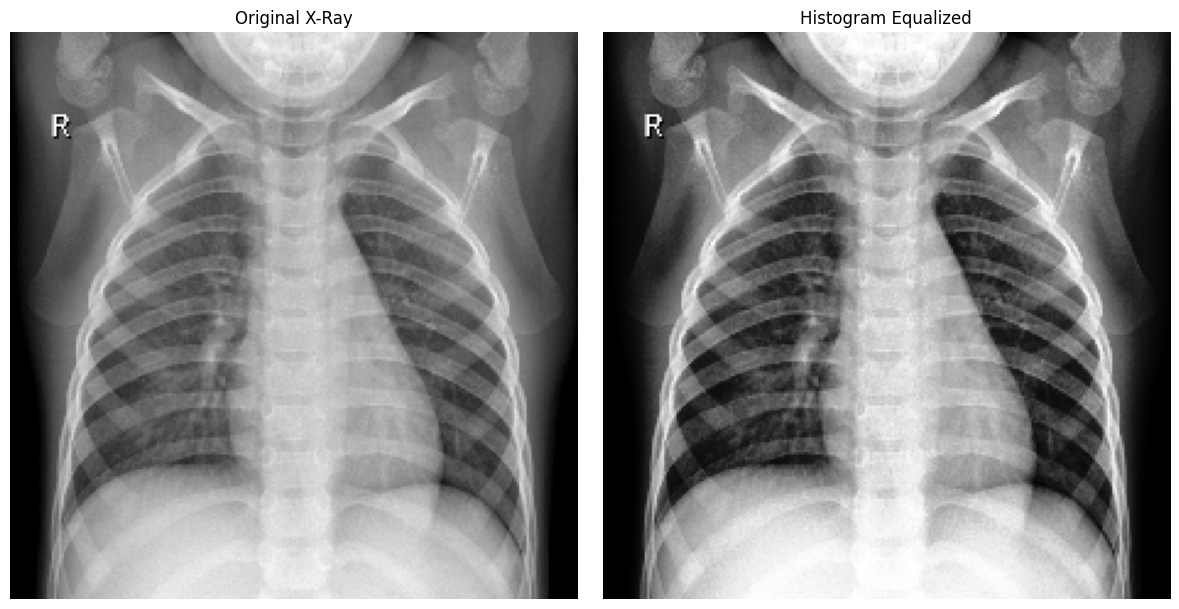

C:\Users\Me\AppData\Local\Temp\ipykernel_2572\3392952153.py:16: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[0].hist(img.ravel(), 256, [0, 256], color='steelblue')
C:\Users\Me\AppData\Local\Temp\ipykernel_2572\3392952153.py:20: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[1].hist(equalized.ravel(), 256, [0, 256], color='coral')


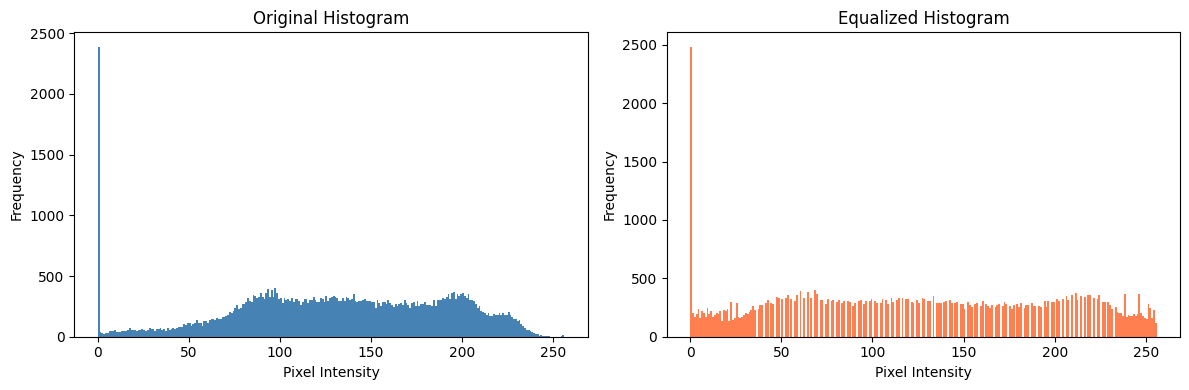

In [3]:
equalized = cv2.equalizeHist(img)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original X-Ray')
axes[0].axis('off')
axes[1].imshow(equalized, cmap='gray')
axes[1].set_title('Histogram Equalized')
axes[1].axis('off')
plt.tight_layout()
plt.savefig('output/02_histogram_equalized.png', dpi=150, bbox_inches='tight')
plt.show()

# Show histogram comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(img.ravel(), 256, [0, 256], color='steelblue')
axes[0].set_title('Original Histogram')
axes[0].set_xlabel('Pixel Intensity')
axes[0].set_ylabel('Frequency')
axes[1].hist(equalized.ravel(), 256, [0, 256], color='coral')
axes[1].set_title('Equalized Histogram')
axes[1].set_xlabel('Pixel Intensity')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('output/02_histogram_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Color Mapping (False-Color Heatmap)
Convert the equalized grayscale image into a false-color heatmap using
OpenCV's `COLORMAP_JET`. This maps pixel intensity to a color spectrum,
helping the human eye detect subtle fluid boundaries and density variations.

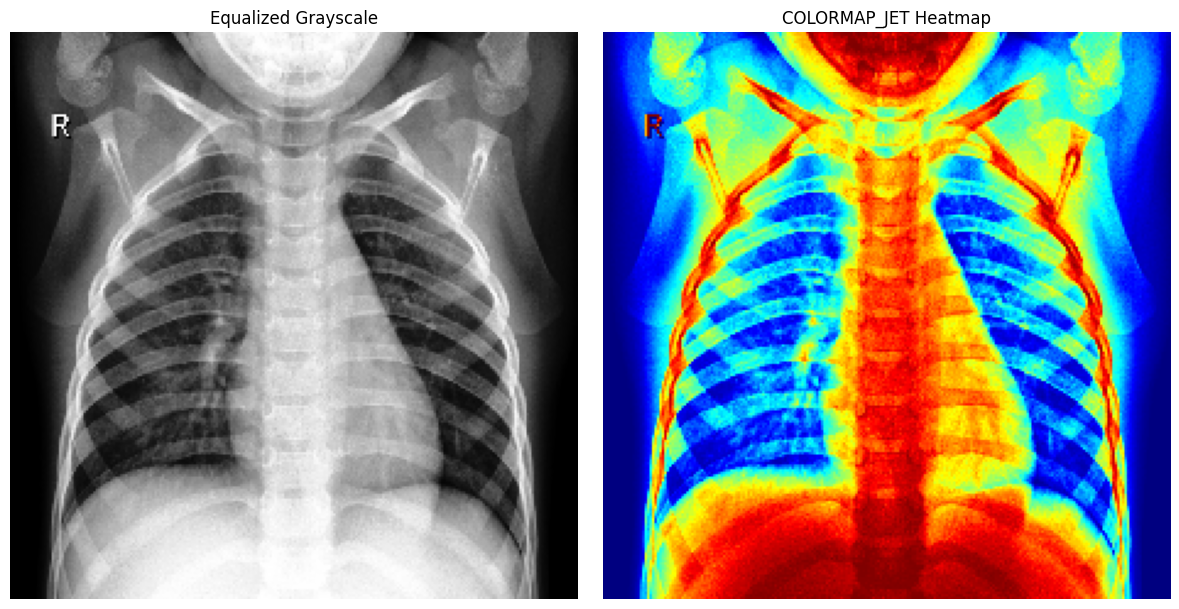

In [4]:
heatmap = cv2.applyColorMap(equalized, cv2.COLORMAP_JET)
heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(equalized, cmap='gray')
axes[0].set_title('Equalized Grayscale')
axes[0].axis('off')
axes[1].imshow(heatmap_rgb)
axes[1].set_title('COLORMAP_JET Heatmap')
axes[1].axis('off')
plt.tight_layout()
plt.savefig('output/03_colormap_jet.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Color Balance
Simulate a lighting correction by applying a mathematical color balance
shift. This neutralizes any artificial color casts in the visualization
by scaling channels toward a white-balanced mean.

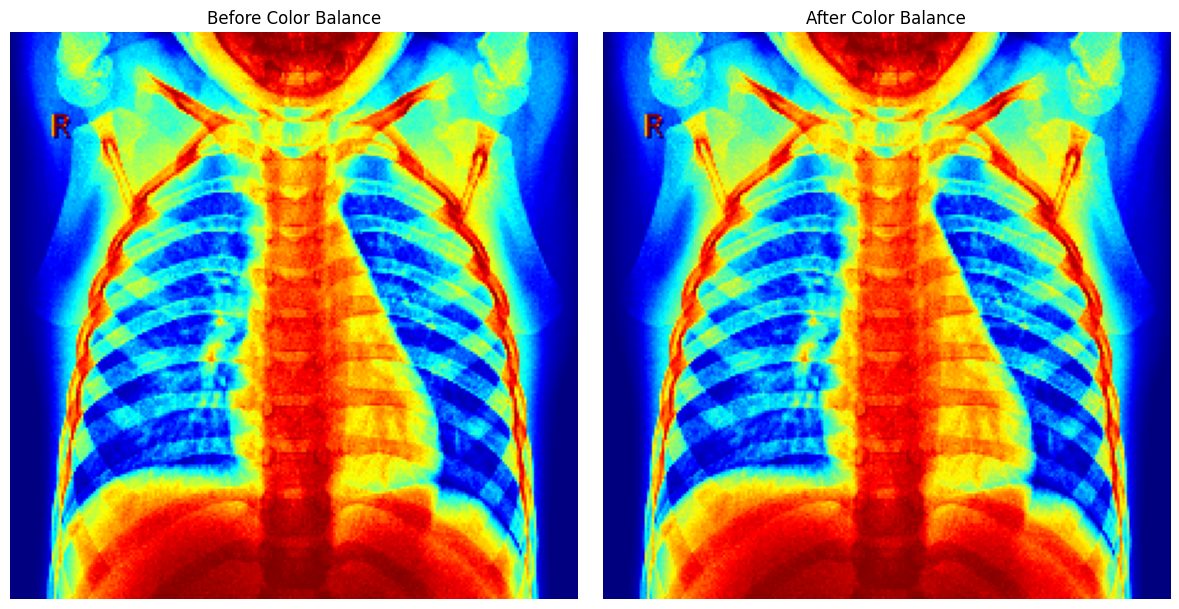

In [5]:
heatmap_float = heatmap_rgb.astype(np.float64)

# Compute per-channel means and overall mean
channel_means = heatmap_float.mean(axis=(0, 1))
overall_mean = channel_means.mean()

# Scale each channel to match the overall mean (Gray World assumption)
balanced = np.zeros_like(heatmap_float)
for i in range(3):
    if channel_means[i] > 0:
        balanced[:, :, i] = heatmap_float[:, :, i] * (overall_mean / channel_means[i])

balanced = np.clip(balanced, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(heatmap_rgb)
axes[0].set_title('Before Color Balance')
axes[0].axis('off')
axes[1].imshow(balanced)
axes[1].set_title('After Color Balance')
axes[1].axis('off')
plt.tight_layout()
plt.savefig('output/04_color_balanced.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Color Filtering (Thresholding)
Dense tissue (bone, fluid) reflects high-intensity values. Apply a strict
threshold to mask out everything except the densest structures, isolating
the ribs, spine, and any fluid build-up.

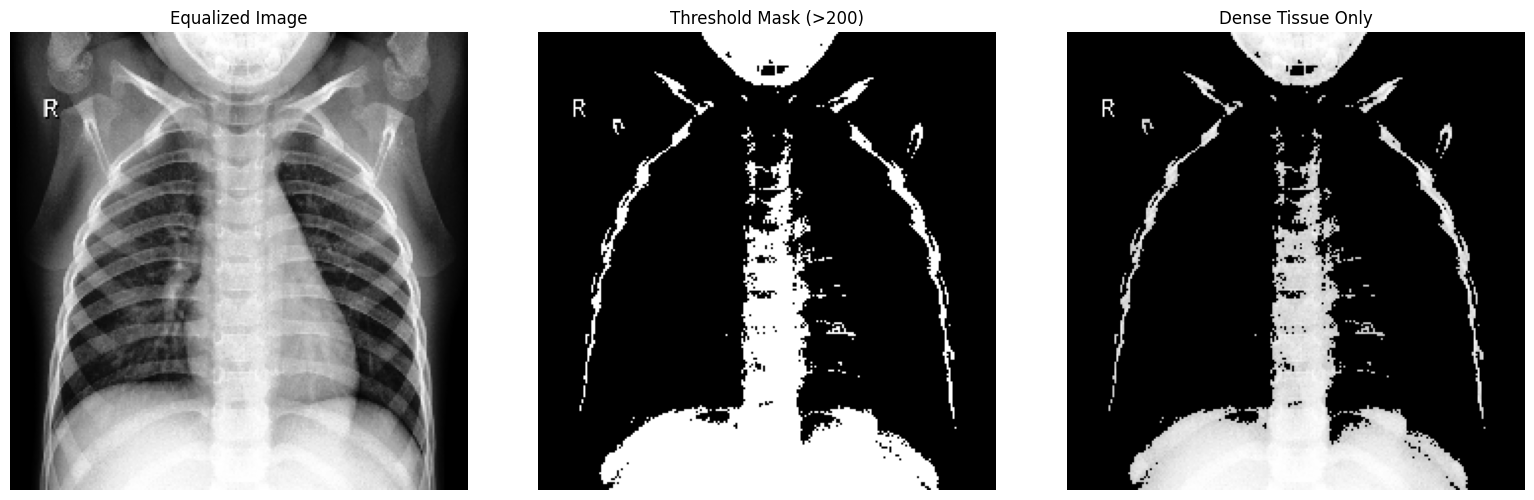

In [6]:
threshold_value = 200
_, dense_mask = cv2.threshold(equalized, threshold_value, 255, cv2.THRESH_BINARY)

# Apply mask to the original equalized image
dense_only = cv2.bitwise_and(equalized, equalized, mask=dense_mask)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(equalized, cmap='gray')
axes[0].set_title('Equalized Image')
axes[0].axis('off')
axes[1].imshow(dense_mask, cmap='gray')
axes[1].set_title(f'Threshold Mask (>{threshold_value})')
axes[1].axis('off')
axes[2].imshow(dense_only, cmap='gray')
axes[2].set_title('Dense Tissue Only')
axes[2].axis('off')
plt.tight_layout()
plt.savefig('output/05_thresholded.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Logarithmic Transformation
Apply a logarithmic curve `s = c * log(1 + r)` to the raw X-ray.
This mathematically expands the dark background regions, revealing the
faint outer edges of the ribcage that are nearly invisible in the original.

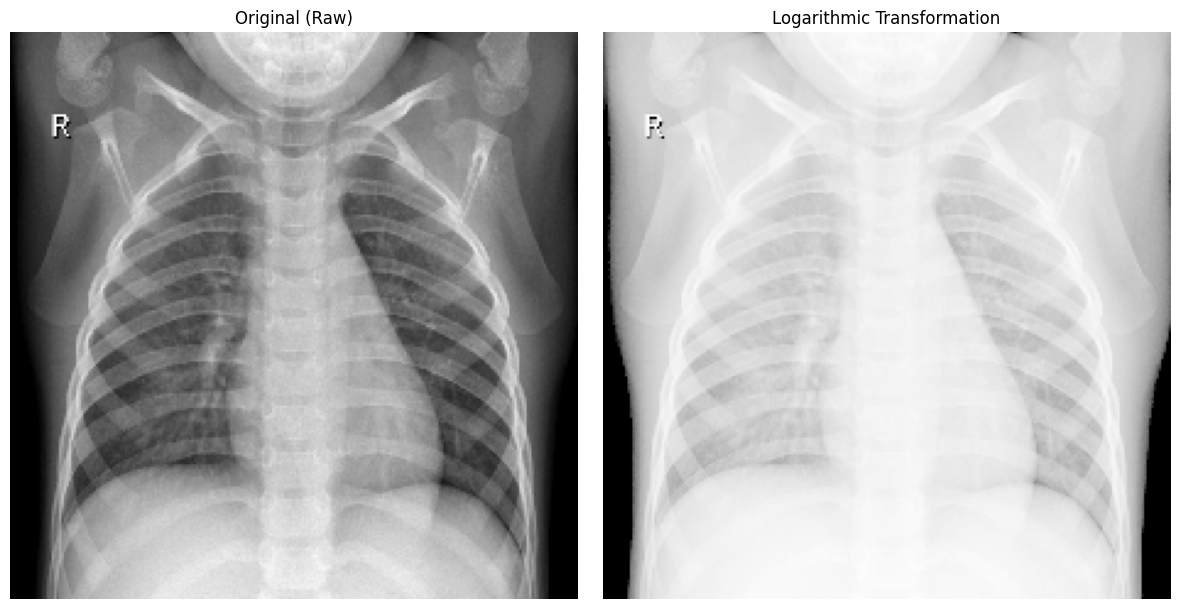

In [7]:
img_float = img.astype(np.float64)
c = 255.0 / np.log(1 + img_float.max())
log_transformed = c * np.log(1 + img_float)
log_transformed = np.clip(log_transformed, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original (Raw)')
axes[0].axis('off')
axes[1].imshow(log_transformed, cmap='gray')
axes[1].set_title('Logarithmic Transformation')
axes[1].axis('off')
plt.tight_layout()
plt.savefig('output/06_log_transform.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Power-Law Transformation (Gamma Correction)
Apply a fractional power-law transformation (γ < 1.0) to fine-tune the
midtones, reducing the harsh contrast of the bones so the soft lung
tissue becomes clearer.

Formula: `s = c * r^γ`  where γ = 0.5

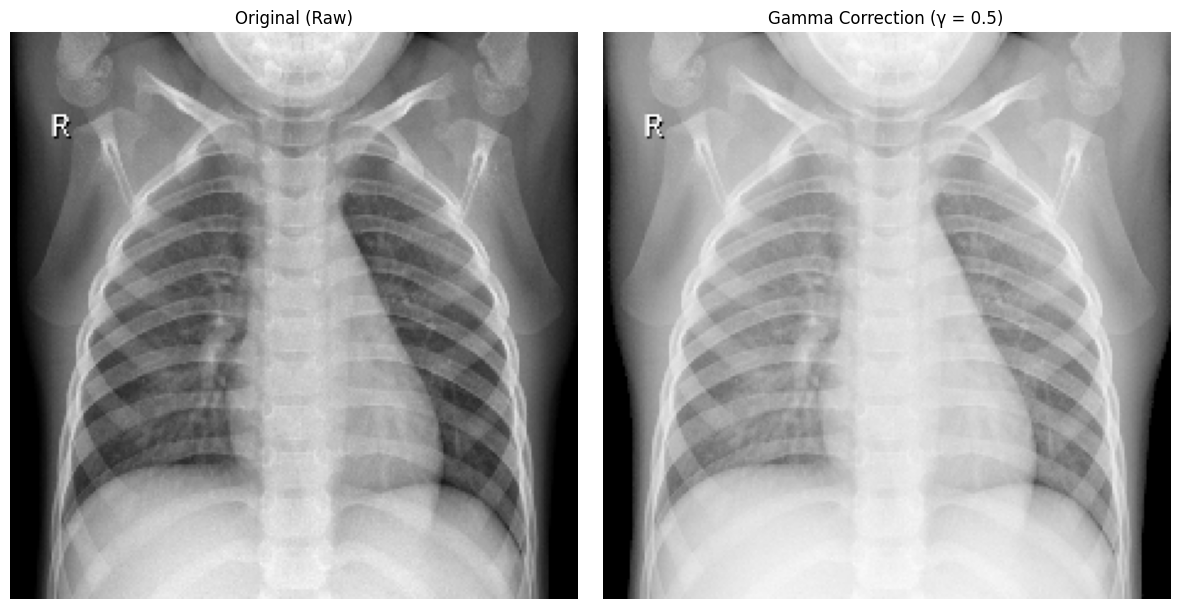

In [8]:
gamma = 0.5
img_normalized = img.astype(np.float64) / 255.0
gamma_corrected = np.power(img_normalized, gamma)
gamma_corrected = (gamma_corrected * 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original (Raw)')
axes[0].axis('off')
axes[1].imshow(gamma_corrected, cmap='gray')
axes[1].set_title(f'Gamma Correction (γ = {gamma})')
axes[1].axis('off')
plt.tight_layout()
plt.savefig('output/07_gamma_correction.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary Comparison
Display all key stages of the pipeline side-by-side.

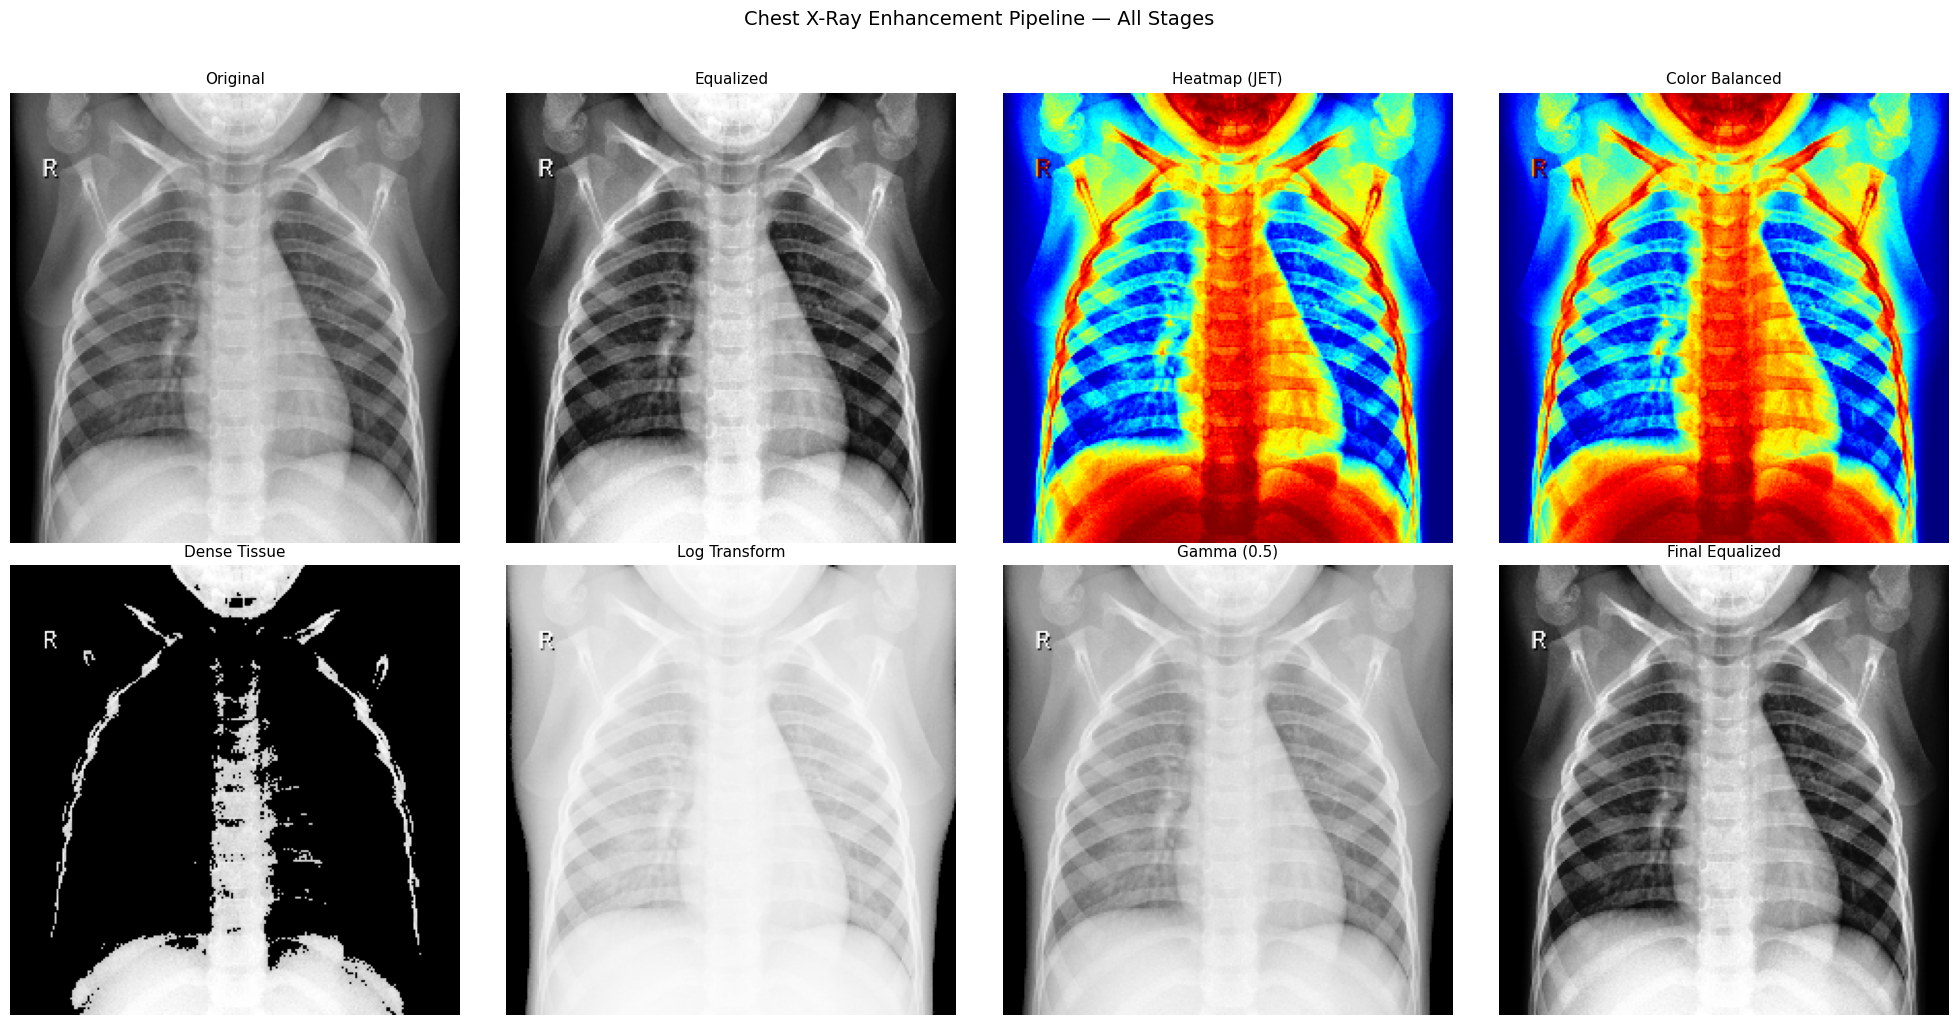

All output images saved to output/ directory.


In [9]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
images = [img, equalized, heatmap_rgb, balanced,
          dense_only, log_transformed, gamma_corrected, equalized]
titles = ['Original', 'Equalized', 'Heatmap (JET)', 'Color Balanced',
          'Dense Tissue', 'Log Transform', 'Gamma (0.5)', 'Final Equalized']
cmaps  = ['gray', 'gray', None, None,
          'gray', 'gray', 'gray', 'gray']

for ax, image, title, cmap in zip(axes.ravel(), images, titles, cmaps):
    ax.imshow(image, cmap=cmap)
    ax.set_title(title, fontsize=11)
    ax.axis('off')

plt.suptitle('Chest X-Ray Enhancement Pipeline — All Stages', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('output/08_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("All output images saved to output/ directory.")